# Traffic Light Detection and State Classification

From-scratch custom edge detection and gradient-optimized 3-D Hough circle voting. The notebook processes **all** images in `images/traffic_lights/`, measures each major stage, and saves report-ready visualizations.

## Constraints respected

No built-in filtering, edge detection, Sobel/Canny, or Hough function is used. Convolution is implemented with NumPy strided windows. Hough voting loops only over candidate radii and uses vectorized voting over all edge pixels along the two gradient-normal directions.

In [1]:
from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import imageio.v3 as iio
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from numpy.lib.stride_tricks import sliding_window_view

# Process overview:
# 1. Load each traffic-light image and resize it to a consistent working scale.
# 2. Build a Canny-like edge map from scratch using Gaussian smoothing, Sobel gradients, NMS, and hysteresis.
# 3. Run gradient-directed Hough circle voting across a range of possible lamp radii.
# 4. Extract strong circle candidates, select the best vertical three-lamp traffic-light group, and classify colors.
# 5. Save diagnostic step figures, final overlays, and report-ready outputs in report_figures.

# Reproducible paths: use the required directory when run from the submission folder.
IMAGE_DIR = Path("images/traffic_lights")
OUTPUT_DIR = Path("report_figures")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)


# Preprocessing: resize images so detection has bounded runtime and comparable scale.
def resize_nearest(image, max_dimension=600):
    """Vectorized nearest-neighbor resizing implemented with NumPy indexing."""
    h, w = image.shape[:2]
    scale = min(1.0, max_dimension / max(h, w))
    new_h, new_w = max(1, round(h * scale)), max(1, round(w * scale))
    y_idx = np.minimum((np.arange(new_h) / scale).astype(int), h - 1)
    x_idx = np.minimum((np.arange(new_w) / scale).astype(int), w - 1)
    return image[y_idx[:, None], x_idx[None, :]], scale


def gaussian_kernel(size=5, sigma=1.2):
    axis = np.arange(size, dtype=np.float32) - size // 2
    xx, yy = np.meshgrid(axis, axis)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / kernel.sum()


def convolve2d_scratch(image, kernel):
    """2-D correlation by a strided window view + einsum; no CV/scipy filter."""
    py, px = kernel.shape[0] // 2, kernel.shape[1] // 2
    padded = np.pad(image, ((py, py), (px, px)), mode="reflect")
    windows = sliding_window_view(padded, kernel.shape)
    return np.einsum("ijkl,kl->ij", windows, kernel, optimize=True)


def shifted(array, dy, dx, fill=-np.inf):
    """Return a non-wrapping shifted view-copy for vectorized neighbor comparison."""
    out = np.full_like(array, fill)
    y_dst = slice(max(0, dy), array.shape[0] + min(0, dy))
    x_dst = slice(max(0, dx), array.shape[1] + min(0, dx))
    y_src = slice(max(0, -dy), array.shape[0] - max(0, dy))
    x_src = slice(max(0, -dx), array.shape[1] - max(0, dx))
    out[y_dst, x_dst] = array[y_src, x_src]
    return out


# Edge detection: convert RGB to grayscale, smooth, compute gradients, thin edges, and link weak edges.
def custom_canny_like(rgb, high_percentile=88, low_ratio=0.40):
    """From-scratch Gaussian smoothing, Sobel gradients, NMS, and hysteresis."""
    gray = (0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]).astype(np.float32)
    smooth = convolve2d_scratch(gray, gaussian_kernel())
    kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    ky = kx.T
    gx = convolve2d_scratch(smooth, kx)
    gy = convolve2d_scratch(smooth, ky)
    magnitude = np.hypot(gx, gy)
    theta = np.arctan2(gy, gx)

    # Non-maximum suppression along one of four quantized gradient directions.
    angle = (np.rad2deg(theta) + 180.0) % 180.0
    nms = np.zeros_like(magnitude)
    directions = [
        ((angle < 22.5) | (angle >= 157.5), (0, 1)),
        ((angle >= 22.5) & (angle < 67.5), (1, 1)),
        ((angle >= 67.5) & (angle < 112.5), (1, 0)),
        ((angle >= 112.5) & (angle < 157.5), (1, -1)),
    ]
    for mask, (dy, dx) in directions:  # only four directions, never pixels
        forward = shifted(magnitude, dy, dx)
        backward = shifted(magnitude, -dy, -dx)
        keep = mask & (magnitude >= forward) & (magnitude >= backward)
        nms[keep] = magnitude[keep]

    nonzero = nms[nms > 0]
    high = np.percentile(nonzero, high_percentile) if nonzero.size else 0.0
    low = low_ratio * high
    strong = nms >= high
    weak = nms >= low

    # Hysteresis by repeated vectorized 8-neighbor dilation.
    edges = strong.copy()
    for _ in range(30):
        padded = np.pad(edges, 1, mode="constant")
        connected = np.zeros_like(edges)
        for oy in range(3):
            for ox in range(3):
                if (oy, ox) != (1, 1):
                    connected |= padded[oy:oy+edges.shape[0], ox:ox+edges.shape[1]]
        updated = strong | (weak & connected)
        if np.array_equal(updated, edges):
            break
        edges = updated
    return gray, smooth, gx, gy, magnitude, theta, edges


# Hough circle detection: vote for circle centers along positive and negative edge-normal directions.
def gradient_hough_circles(edges, gx, gy, radii):
    """3-D (radius,y,x) accumulator; votes only along +/- edge normals."""
    ys, xs = np.nonzero(edges)
    local_mag = np.hypot(gx[ys, xs], gy[ys, xs])
    valid_grad = local_mag > 1e-6
    ys, xs, local_mag = ys[valid_grad], xs[valid_grad], local_mag[valid_grad]
    ux = gx[ys, xs] / local_mag
    uy = gy[ys, xs] / local_mag

    height, width = edges.shape
    accumulator = np.zeros((len(radii), height, width), dtype=np.uint16)
    for radius_index, radius in enumerate(radii):  # vectorized across every edge point
        for sign in (-1, 1):
            cx = np.rint(xs + sign * radius * ux).astype(np.int32)
            cy = np.rint(ys + sign * radius * uy).astype(np.int32)
            inside = (cx >= 0) & (cx < width) & (cy >= 0) & (cy < height)
            np.add.at(accumulator[radius_index], (cy[inside], cx[inside]), 1)
    return accumulator


# Candidate filtering: keep high-score circles while suppressing near-duplicate detections.
def extract_candidates(accumulator, radii, candidate_count=60):
    """Obtain sparse local candidates from the 3-D volume with greedy NMS."""
    normalized = accumulator.astype(np.float32) / np.sqrt(np.asarray(radii)[:, None, None])
    flat = normalized.ravel()
    pool_size = min(candidate_count * 25, flat.size)
    pool = np.argpartition(flat, -pool_size)[-pool_size:]
    pool = pool[np.argsort(flat[pool])[::-1]]
    candidates = []
    for index in pool:
        ri, y, x = np.unravel_index(index, normalized.shape)
        radius, score = int(radii[ri]), float(normalized[ri, y, x])
        distinct = all(
            (x-x0)**2 + (y-y0)**2 > (0.70 * max(radius, r0))**2
            or abs(radius-r0) > 0.50 * max(radius, r0)
            for x0, y0, r0, _ in candidates
        )
        if distinct:
            candidates.append((x, y, radius, score))
        if len(candidates) == candidate_count:
            break
    return candidates, normalized


# Lamp-state classification: estimate the dominant active color inside each detected circle.
def classify_circle(rgb, x, y, radius):
    """Classify active hue from RGB dominance; low brightness/saturation => UNLIT."""
    height, width = rgb.shape[:2]
    yy, xx = np.ogrid[:height, :width]
    inside = (xx-x)**2 + (yy-y)**2 <= (0.70 * radius)**2
    pixels = rgb[inside].astype(np.float32) / 255.0
    if pixels.size == 0:
        return "UNLIT", 0.0
    red, green, blue = pixels[:, 0], pixels[:, 1], pixels[:, 2]
    value = pixels.max(axis=1)
    saturation = (value - pixels.min(axis=1)) / (value + 1e-6)
    scores = {
        "RED": np.mean(np.clip(red - (green+blue)/2, 0, None) * value),
        "GREEN": np.mean(np.clip(green - (red+blue)/2, 0, None) * value),
        "YELLOW": np.mean(np.clip(np.minimum(red, green) - blue, 0, None) * value),
    }
    label = max(scores, key=scores.get)
    active = (np.mean(value > 0.45) > 0.08 and scores[label] > 0.025 and np.mean(saturation) > 0.18)
    return (label if active else "UNLIT"), float(scores[label])


# Traffic-light grouping: rank circles and keep the most plausible vertical three-lamp layout.
def select_traffic_light_triplet(rgb, candidates):
    """Rank circles and select a vertical, similarly-sized three-lamp arrangement."""
    gray = (0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]) / 255.0
    height, width = gray.shape
    yy, xx = np.ogrid[:height, :width]
    ranked = []
    min_radius = 0.05 * min(height, width)
    for x, y, radius, hough_score in candidates:
        if radius < min_radius or x-radius < 0 or y-radius < 0 or x+radius >= width or y+radius >= height:
            continue
        distance2 = (xx-x)**2 + (yy-y)**2
        interior = distance2 < (0.72*radius)**2
        ring = (distance2 > (0.82*radius)**2) & (distance2 < (1.18*radius)**2)
        contrast = abs(float(gray[interior].mean()) - float(gray[ring].mean()))
        label, color_score = classify_circle(rgb, x, y, radius)
        total = hough_score + 8.0*contrast + 20.0*color_score
        ranked.append((total, x, y, radius, label, hough_score, contrast, color_score))
    ranked.sort(reverse=True)

    best = None
    top = ranked[:30]
    for i in range(len(top)):
        for j in range(i+1, len(top)):
            for k in range(j+1, len(top)):
                group = sorted([top[i], top[j], top[k]], key=lambda item: item[2])
                radii = np.array([item[3] for item in group], dtype=float)
                xs = np.array([item[1] for item in group], dtype=float)
                ys = np.array([item[2] for item in group], dtype=float)
                mean_r = radii.mean()
                gaps = np.diff(ys)
                if radii.max()/radii.min() > 1.5:
                    continue
                if np.ptp(xs) > 1.1*mean_r or np.any(gaps < 1.0*mean_r) or np.any(gaps > 3.5*mean_r):
                    continue
                geometry_penalty = (np.std(xs)+np.std(radii)+abs(gaps[0]-gaps[1]))/(mean_r+1e-6)
                total = sum(item[0] for item in group) - 4.0*geometry_penalty
                if best is None or total > best[0]:
                    best = (total, group)
    chosen = best[1] if best else ranked[:3]
    return [(int(z[1]), int(z[2]), int(z[3]), z[4], float(z[0])) for z in chosen]


# Per-image pipeline: execute all processing stages and record timing for the report.
def run_one(path, max_dimension=600):
    timings = {}
    t0 = perf_counter()
    original = iio.imread(path)[..., :3]
    rgb, scale = resize_nearest(original, max_dimension=max_dimension)
    timings["Preprocessing"] = perf_counter() - t0

    t0 = perf_counter()
    gray, smooth, gx, gy, magnitude, theta, edges = custom_canny_like(rgb)
    timings["Edge Detection"] = perf_counter() - t0

    max_dim = max(rgb.shape[:2])
    radii = np.arange(max(8, int(0.015*max_dim)), max(16, int(0.11*max_dim)), 2, dtype=int)
    t0 = perf_counter()
    accumulator = gradient_hough_circles(edges, gx, gy, radii)
    timings["Hough Voting"] = perf_counter() - t0

    t0 = perf_counter()
    candidates, normalized = extract_candidates(accumulator, radii)
    detections = select_traffic_light_triplet(rgb, candidates)
    timings["Post-processing"] = perf_counter() - t0
    timings["Total"] = sum(timings.values())
    return {
        "name": path.stem, "rgb": rgb, "gray": gray, "edges": edges,
        "accumulator": accumulator, "normalized": normalized, "radii": radii,
        "detections": detections, "timings": timings, "scale": scale
    }


# Reporting outputs: save intermediate visualizations and final yellow-circle overlays.
def save_step_figure(result):
    fig, axes = plt.subplots(1, 4, figsize=(15, 4.2))
    axes[0].imshow(result["rgb"]); axes[0].set_title("Original (resized)")
    axes[1].imshow(result["edges"], cmap="gray"); axes[1].set_title("Custom edge map")
    heatmap = result["normalized"].max(axis=0)
    axes[2].imshow(heatmap, cmap="hot"); axes[2].set_title("Max over 3-D Hough radii")
    axes[3].imshow(result["rgb"]); axes[3].set_title("Detected lamps and states")
    for x, y, r, label, _ in result["detections"]:
        axes[3].add_patch(Circle((x, y), r, fill=False, linewidth=2, edgecolor="yellow"))
        axes[3].text(x-r, max(10, y-r-4), label, fontsize=9,
                     bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
    for ax in axes: ax.axis("off")
    fig.tight_layout()
    out = OUTPUT_DIR / f"{result['name']}_steps.png"
    fig.savefig(out, dpi=170, bbox_inches="tight")
    plt.close(fig)
    return out


def save_overlay(result):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.imshow(result["rgb"])
    for x, y, r, label, _ in result["detections"]:
        ax.add_patch(Circle((x, y), r, fill=False, linewidth=2.5, edgecolor="yellow"))
        ax.text(x-r, max(12, y-r-5), label, fontsize=11, weight="bold",
                bbox=dict(facecolor="white", alpha=0.78, edgecolor="none"))
    ax.axis("off"); fig.tight_layout()
    out = OUTPUT_DIR / f"{result['name']}_overlay.png"
    fig.savefig(out, dpi=170, bbox_inches="tight")
    plt.close(fig)
    return out


## Run the complete dataset

In [2]:
image_paths = sorted(IMAGE_DIR.glob('*'))
image_paths = [p for p in image_paths if p.suffix.lower() in {'.png','.jpg','.jpeg','.bmp'}]
assert image_paths, f'No images found in {IMAGE_DIR.resolve()}'
results = [run_one(path) for path in image_paths]
for result in results:
    save_step_figure(result)
    save_overlay(result)
print(f'Processed {len(results)} images.')

Processed 3 images.


## Detected states

In [3]:
rows=[]
for result in results:
    for order,(x,y,r,label,score) in enumerate(result['detections'], start=1):
        rows.append({'image':result['name'],'lamp_top_to_bottom':order,'center_x':x,'center_y':y,'radius':r,'state':label})
detection_table=pd.DataFrame(rows)
detection_table

,image,lamp_top_to_bottom,center_x,center_y,radius,state
0,green_light_1,1,454,76,37,UNLIT
1,green_light_1,2,456,177,39,UNLIT
2,green_light_1,3,455,278,35,GREEN
3,red_light_1,1,322,60,35,RED
4,red_light_1,2,320,133,33,UNLIT
5,red_light_1,3,317,217,33,UNLIT
6,red_light_2,1,406,133,25,RED
7,red_light_2,2,392,197,31,UNLIT
8,red_light_2,3,392,273,31,UNLIT


## Execution profiling

In [4]:
timing_table = pd.DataFrame([{'image':r['name'], **r['timings']} for r in results])
average_row = {'image':'AVERAGE', **timing_table.drop(columns='image').mean().to_dict()}
timing_table = pd.concat([timing_table, pd.DataFrame([average_row])], ignore_index=True)
timing_table.round(4)

,image,Preprocessing,Edge Detection,Hough Voting,Post-processing,Total
0,green_light_1,0.0580,0.0300,0.0313,0.3553,0.4747
1,red_light_1,0.0058,0.0255,0.0237,0.2738,0.3288
2,red_light_2,0.0144,0.0314,0.0461,0.3157,0.4076
3,AVERAGE,0.0261,0.0290,0.0337,0.3150,0.4037


## Step-by-step outputs

green_light_1


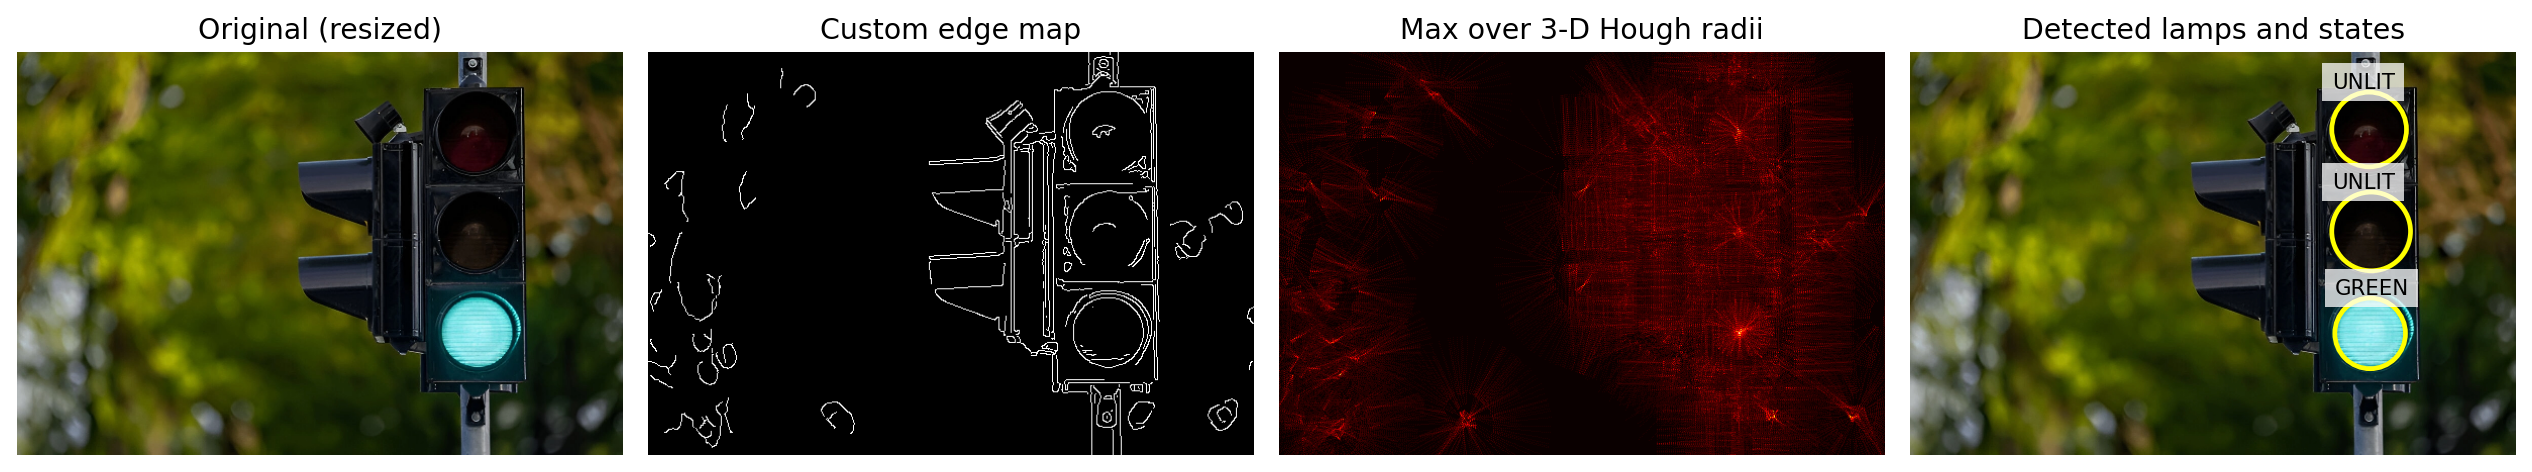

red_light_1


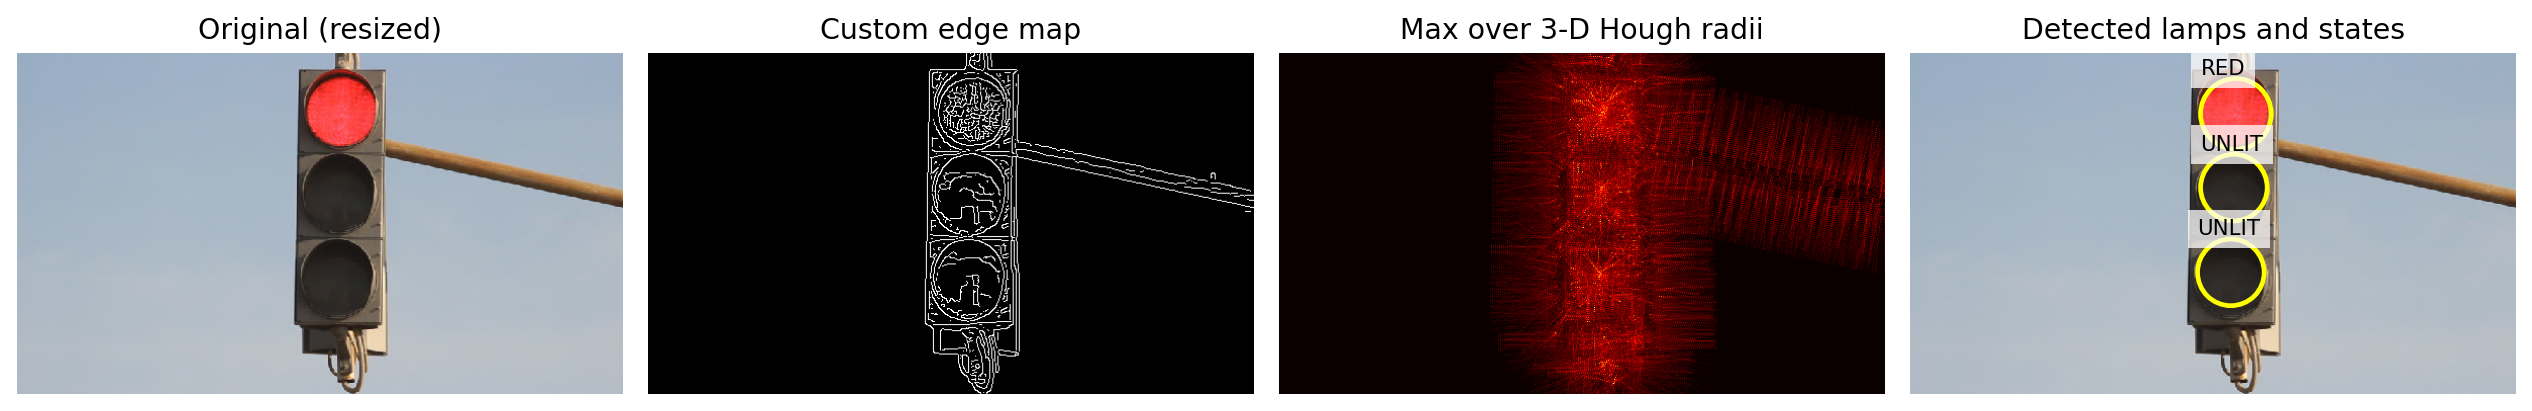

red_light_2


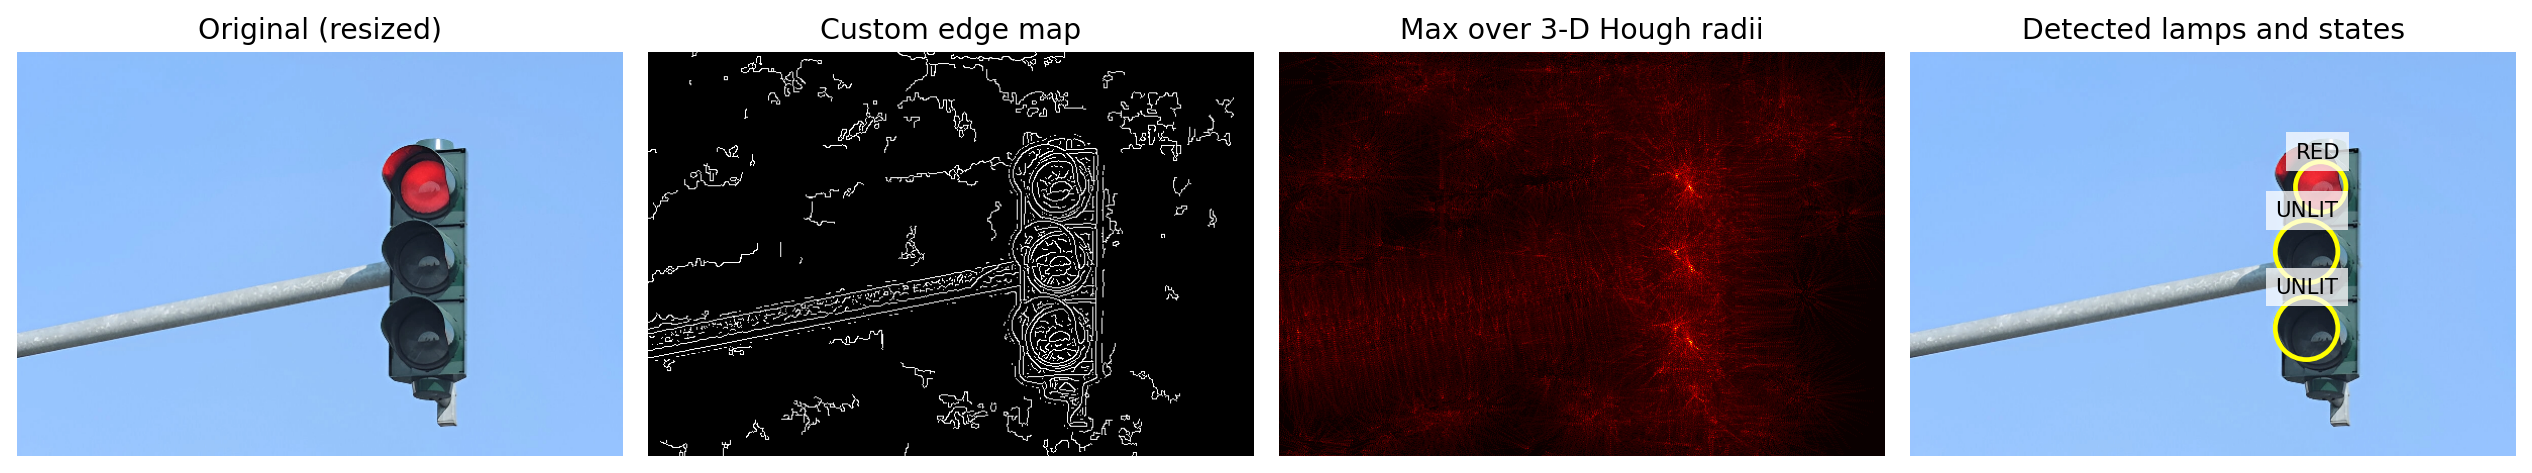

In [5]:
from IPython.display import display, Image
for result in results:
    print(result['name'])
    display(Image(filename=str(OUTPUT_DIR / f"{result['name']}_steps.png")))

## Notes on complexity

For `E` edge pixels and `R` radii, the voting cost is approximately `O(E R)`: each edge point casts only two votes per radius. This replaces the brute-force angular sweep, approximately `O(E R A)`, where `A` is the number of sampled angles. The accumulator still has the required 3-D shape `(R,H,W)`.

# Save figures

In [6]:
from pathlib import Path

REPORT_DIR = Path("report_figures")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Save any currently open matplotlib figures
for fig_num in plt.get_fignums():
    fig = plt.figure(fig_num)
    fig.savefig(REPORT_DIR / f"figure_{fig_num:02d}.png", dpi=300, bbox_inches="tight")

# Save generated tables
tables = {
    "detection_table": detection_table,
    "timing_table": timing_table.round(4),
}

for name, table in tables.items():
    table.to_csv(REPORT_DIR / f"{name}.csv", index=False)
    table.to_html(REPORT_DIR / f"{name}.html", index=False)
    table.to_latex(REPORT_DIR / f"{name}.tex", index=False)

print(f"Saved figures and tables to: {REPORT_DIR.resolve()}")

Saved figures and tables to: C:\Users\Mana\OneDrive\Desktop\CE\Masters\Term 2\DIP\HW\3\DIP-HW3-gpt\report_figures
